# 03 · Text Similarity — Captions Across Personas

For each image, multiple persona-driven annotators produced a caption.
This notebook measures **how similar those captions are** using sentence-level cosine similarity.

**Research question**: How much do personas converge (or diverge) in the way they describe the same urban scene? Which persona groups agree least?

**Method**: Encode all captions with `sentence-transformers/all-MiniLM-L6-v2`, then compute pairwise cosine similarity among captions for the same `image_id`. Summarize per-image and per-persona-pair.

In [1]:
import json as _json
import json
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

DATA_PATH = Path("../data/annotations_baseline.jsonl")
FIGURES   = Path("../figures")
OUTPUTS   = Path("../outputs")

FONT_SCALE = 1.4
sns.set_theme(style="whitegrid", font_scale=FONT_SCALE)
plt.rcParams["figure.dpi"] = 150

records = [json.loads(l) for l in DATA_PATH.open()]
df = pd.DataFrame(records)
print(f"Records: {len(df):,} | Images: {df['image_id'].nunique():,} | Personas: {df['persona_id'].nunique():,}")

MUTED = sns.color_palette("muted")  # [#4878d0, #ee854a, #6acc64, #d65f5f, ...]
SENT_COLORS = {
    "Negative":         "#d73027",
    "SlightlyNegative": "#fc8d59",
    "Neutral":          "#aaaaaa",
    "SlightlyPositive": "#91cf60",
    "Positive":         "#1a9850",
}
SENT_COLORS_3 = {k: SENT_COLORS[k] for k in ["Negative", "Neutral", "Positive"]}


Records: 59,708 | Images: 50 | Personas: 1,200


## 1 · Encode captions with SentenceTransformer

In [2]:
EMBED_CACHE = OUTPUTS / "caption_embeddings.npy"
ID_CACHE    = OUTPUTS / "caption_embeddings_ids.csv"

if EMBED_CACHE.exists():
    embeddings = np.load(EMBED_CACHE)
    id_df = pd.read_csv(ID_CACHE)
    df = df.merge(id_df, on="annotation_id", how="left")
    print(f"Loaded cached embeddings: {embeddings.shape}")
else:
    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    captions = df["caption"].tolist()
    embeddings = model.encode(captions, batch_size=256, show_progress_bar=True,
                              normalize_embeddings=True)
    np.save(EMBED_CACHE, embeddings)
    df[["annotation_id"]].to_csv(ID_CACHE, index=False)
    print(f"Computed and saved embeddings: {embeddings.shape}")

Loaded cached embeddings: (59708, 384)


## 2 · Per-image mean cosine similarity

In [3]:
SIMILARITY_CACHE = OUTPUTS / "per_image_cosine_similarity.csv"

if SIMILARITY_CACHE.exists():
    sim_df = pd.read_csv(SIMILARITY_CACHE)
    print(f"Loaded cached per-image similarities: {len(sim_df):,} rows")
else:
    embed_idx = {aid: i for i, aid in enumerate(df["annotation_id"])}
    rows = []
    for img_id, group in tqdm(df.groupby("image_id"), desc="Per-image similarity"):
        idx = [embed_idx[aid] for aid in group["annotation_id"]]
        embs = embeddings[idx]
        if len(embs) < 2:
            continue
        sim_matrix = cosine_similarity(embs)
        # upper-triangle excluding diagonal
        upper = sim_matrix[np.triu_indices(len(embs), k=1)]
        rows.append({
            "image_id": img_id,
            "mean_sim": upper.mean(),
            "std_sim":  upper.std(),
            "min_sim":  upper.min(),
            "max_sim":  upper.max(),
            "n_personas": len(embs),
        })
    sim_df = pd.DataFrame(rows)
    sim_df.to_csv(SIMILARITY_CACHE, index=False)
    print(f"Saved {len(sim_df):,} per-image similarity records")

sim_df.describe().round(4)

Loaded cached per-image similarities: 50 rows


,mean_sim,std_sim,min_sim,max_sim,n_personas
count,50.0000,50.0000,50.0000,50.0,50.0000
mean,0.8727,0.0854,0.1271,1.0,1194.1600
std,0.0734,0.0262,0.1617,0.0,26.8939
min,0.6337,0.0393,-0.0568,1.0,1015.0000
25%,0.8356,0.0662,0.0276,1.0,1199.0000
50%,0.8753,0.0779,0.0545,1.0,1200.0000
75%,0.9250,0.0938,0.1810,1.0,1200.0000
max,0.9798,0.1614,0.5684,1.0,1200.0000


## 3 · Distribution of per-image mean cosine similarity

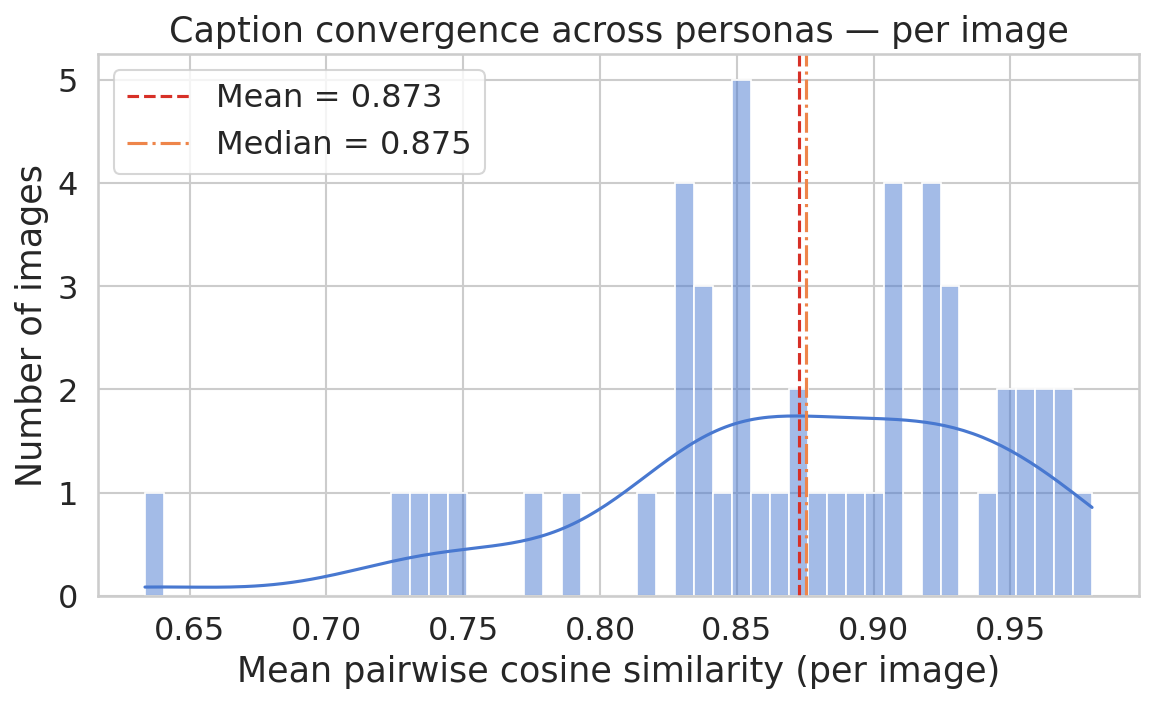

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(sim_df["mean_sim"], bins=50, kde=True, color=MUTED[0], ax=ax)
ax.axvline(sim_df["mean_sim"].mean(), color="#d73027", linestyle="--",
           label=f"Mean = {sim_df['mean_sim'].mean():.3f}")
ax.axvline(sim_df["mean_sim"].median(), color=MUTED[1], linestyle="-.",
           label=f"Median = {sim_df['mean_sim'].median():.3f}")
ax.set_xlabel("Mean pairwise cosine similarity (per image)")
ax.set_ylabel("Number of images")
ax.set_title("Caption convergence across personas — per image")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / "fig_sim_per_image_dist.pdf")
fig.savefig(FIGURES / "fig_sim_per_image_dist.png")
plt.show()


## 4 · Images with lowest/highest agreement

In [5]:
print("=== Lowest mean similarity (most divergent) ===")
print(sim_df.nsmallest(10, "mean_sim")[["image_id", "mean_sim", "std_sim", "n_personas"]].to_string(index=False))
print()
print("=== Highest mean similarity (most convergent) ===")
print(sim_df.nlargest(10, "mean_sim")[["image_id", "mean_sim", "std_sim", "n_personas"]].to_string(index=False))

=== Lowest mean similarity (most divergent) ===
                         image_id  mean_sim  std_sim  n_personas
1sfAJ-SYopUN1Hy20CmVASpKh0CmPGliN  0.633657 0.143286        1200
1eV8XkQbq8rECy6hbZrN1_qwSRyWXDqsK  0.728216 0.144428        1199
103V6ocF--_BPMnZoK9eUxTWbIZG2QsHG  0.734337 0.118839        1200
1Q_gMcjg8yrq2M7OCj1uBySMtP03fZgx-  0.743080 0.161446        1200
1RL3a1P0MAEe7b91QhSX-L6oBRP76YNZm  0.750685 0.090998        1197
16nwQtJeucg4qnhhT7vOZlCThfWr9ldn8  0.777264 0.095104        1195
1d_N60_USocfCq3b1PUo6ggQ0uXm7fxyP  0.787212 0.149029        1200
1E7sGHkf9mgoSumKn_Oj9wLe8eymnUuig  0.820437 0.106870        1199
1khAXDwBS9Lwg4diDT7HjvdqavZ6qRPrX  0.828335 0.066195        1194
10ha6FXS8e5O7LoMJMasGsqRPE_9V8tk4  0.830848 0.088102        1200

=== Highest mean similarity (most convergent) ===
                         image_id  mean_sim  std_sim  n_personas
1r7ff1KflZ1FUAQO6k9fhsHzpsmUdsFq4  0.979815 0.048153        1200
14oyRi0Ae7uRpRiJRw1lPfwwhhldXC84U  0.972518 0.061438    

## 5 · Per-persona mean cosine similarity (how often each persona agrees with others)

In [6]:
PERSONA_SIM_CACHE = OUTPUTS / "per_persona_cosine_similarity.csv"

if PERSONA_SIM_CACHE.exists():
    persona_sim_df = pd.read_csv(PERSONA_SIM_CACHE)
    print("Loaded cached per-persona similarities.")
else:
    embed_idx = {aid: i for i, aid in enumerate(df["annotation_id"])}
    persona_rows = []

    for img_id, group in tqdm(df.groupby("image_id"), desc="Per-persona similarity"):
        grp = group.reset_index(drop=True)
        idx = [embed_idx[aid] for aid in grp["annotation_id"]]
        embs = embeddings[idx]
        if len(embs) < 2:
            continue
        sim_matrix = cosine_similarity(embs)
        for i in range(len(grp)):
            others = [sim_matrix[i, j] for j in range(len(grp)) if j != i]
            persona_rows.append({
                "persona_id": grp.loc[i, "persona_id"],
                "image_id": img_id,
                "mean_sim_vs_others": np.mean(others),
            })

    persona_sim_df = pd.DataFrame(persona_rows)
    persona_sim_df.to_csv(PERSONA_SIM_CACHE, index=False)
    print(f"Saved {len(persona_sim_df):,} persona-level similarity records")

per_persona = (
    persona_sim_df.groupby("persona_id")["mean_sim_vs_others"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean")
)
print(per_persona.describe().round(4))

Loaded cached per-persona similarities.
            mean        std
count  1200.0000  1200.0000
mean      0.8724     0.0858
std       0.0066     0.0138
min       0.8347     0.0660
25%       0.8688     0.0787
50%       0.8731     0.0827
75%       0.8768     0.0878
max       0.8910     0.1782


## 6 · Boxplot — caption similarity by predicted sentiment

/tmp/ipykernel_78212/2804074115.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sim_sent[sim_sent["majority_sentiment"].isin(order)],


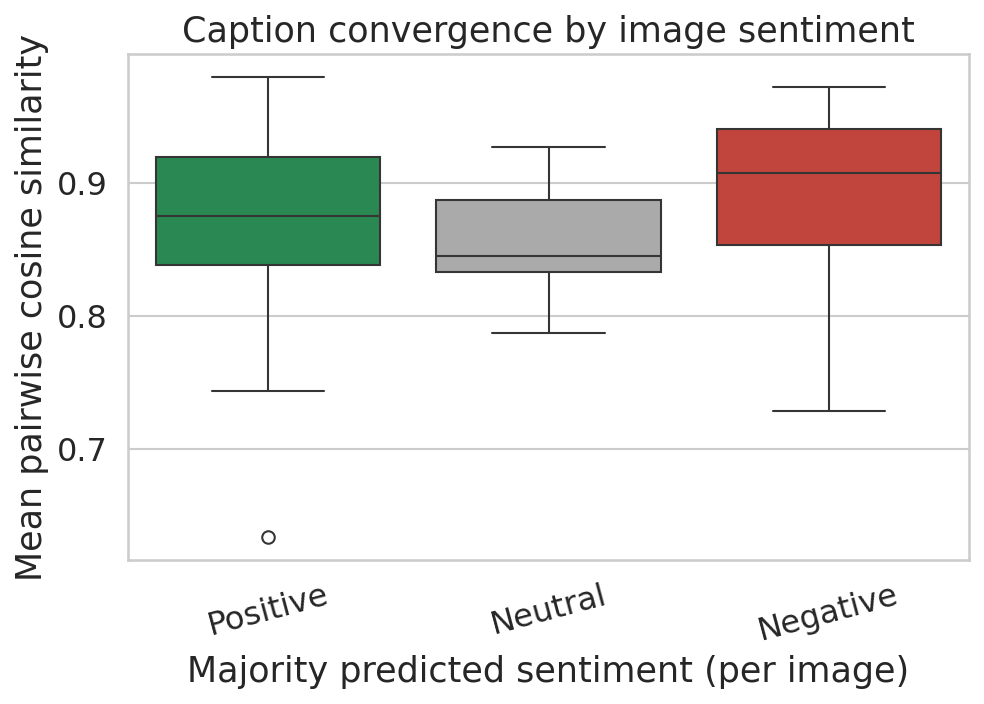

In [7]:
img_sentiment = (
    df.groupby("image_id")["predicted_sentiment"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
    .rename(columns={"predicted_sentiment": "majority_sentiment"})
)
sim_sent = sim_df.merge(img_sentiment, on="image_id")

order = ["Positive", "Neutral", "Negative"]
fig, ax = plt.subplots(figsize=(7, 5))
bp_palette = [SENT_COLORS_3[s] for s in order]
sns.boxplot(data=sim_sent[sim_sent["majority_sentiment"].isin(order)],
            x="majority_sentiment", y="mean_sim", order=order,
            palette=bp_palette, ax=ax)
ax.set_xlabel("Majority predicted sentiment (per image)")
ax.set_ylabel("Mean pairwise cosine similarity")
ax.set_title("Caption convergence by image sentiment")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
fig.savefig(FIGURES / "fig_sim_by_sentiment.pdf")
fig.savefig(FIGURES / "fig_sim_by_sentiment.png")
plt.show()


## 7 · Save summary for use in paper

In [8]:
summary = sim_df[["mean_sim", "std_sim", "min_sim", "max_sim"]].describe().round(4)
print(summary)
summary.to_csv(OUTPUTS / "caption_similarity_summary.csv")

       mean_sim  std_sim  min_sim  max_sim
count   50.0000  50.0000  50.0000     50.0
mean     0.8727   0.0854   0.1271      1.0
std      0.0734   0.0262   0.1617      0.0
min      0.6337   0.0393  -0.0568      1.0
25%      0.8356   0.0662   0.0276      1.0
50%      0.8753   0.0779   0.0545      1.0
75%      0.9250   0.0938   0.1810      1.0
max      0.9798   0.1614   0.5684      1.0


## 8 · Justification text similarity (per image)

Mirrors the caption analysis of sections 2–6, applied to *justification* embeddings.
Since justifications are written in the persona's own voice, we expect lower convergence
than captions (which are instructed to be objective).

In [ ]:
JUST_EMBED_CACHE = OUTPUTS / "justification_embeddings.npy"
JUST_SIM_CACHE   = OUTPUTS / "per_image_just_similarity.csv"

just_embeddings = np.load(JUST_EMBED_CACHE)
print(f"Justification embeddings: {just_embeddings.shape}")

if JUST_SIM_CACHE.exists():
    just_sim_df = pd.read_csv(JUST_SIM_CACHE)
    print(f"Loaded cached per-image justification similarities: {len(just_sim_df):,} rows")
else:
    # justification_embeddings are in the same row order as df
    embed_idx_j = {i: i for i in range(len(df))}
    df_reset = df.reset_index(drop=True)
    rows_j = []
    for img_id, group in tqdm(df_reset.groupby("image_id"), desc="Just similarity"):
        idx = group.index.tolist()
        embs = just_embeddings[idx]
        if len(embs) < 2:
            continue
        from sklearn.metrics.pairwise import cosine_similarity as _cs
        sim_matrix = _cs(embs)
        upper = sim_matrix[np.triu_indices(len(embs), k=1)]
        rows_j.append({
            "image_id":    img_id,
            "mean_just_sim": upper.mean(),
            "std_just_sim":  upper.std(),
            "min_just_sim":  upper.min(),
            "max_just_sim":  upper.max(),
            "n_personas":    len(embs),
        })
    just_sim_df = pd.DataFrame(rows_j)
    just_sim_df.to_csv(JUST_SIM_CACHE, index=False)
    print(f"Saved {len(just_sim_df):,} per-image justification similarity records")

just_sim_df.describe().round(4)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_, col, title in zip(
    axes,
    [sim_df, just_sim_df],
    ["mean_sim", "mean_just_sim"],
    ["Caption similarity", "Justification similarity"],
):
    sns.histplot(df_[col], bins=30, kde=True, color=MUTED[0], ax=ax)
    ax.axvline(df_[col].mean(),   color="#d73027", linestyle="--",
               label=f"Mean = {df_[col].mean():.3f}")
    ax.axvline(df_[col].median(), color=MUTED[1],  linestyle="-.",
               label=f"Median = {df_[col].median():.3f}")
    ax.set_xlabel(f"Mean pairwise cosine similarity (per image)")
    ax.set_ylabel("Number of images")
    ax.set_title(title)
    ax.legend()

plt.suptitle("Caption vs. justification convergence across personas", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / "fig_just_sim_vs_caption_sim.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_just_sim_vs_caption_sim.png", bbox_inches="tight")
plt.show()


## 9 · Within-persona vs. cross-persona text similarity

**Research question (Thiago):** Do agents with the *same* persona profile
produce more similar captions and justifications than agents with *different* profiles?

For each demographic dimension (gender, economic status, political spectrum, personality)
we split all pairwise similarities per image into *within-group* (same attribute level)
and *cross-group* (different attribute level) pairs, then compare their distributions.

This mirrors the UrbCom convergence structure but applied to text descriptions
rather than sentiment labels.

In [ ]:
import ast as _ast

# ── Parse raw_demographics ────────────────────────────────────────────────
def _parse_demo(raw):
    if isinstance(raw, dict):
        return raw
    try:
        return _ast.literal_eval(raw)
    except Exception:
        return {}

demo_cols = ["gender", "economic_status", "political_spectrum", "personality"]
_demo_df = df["raw_demographics"].apply(_parse_demo).apply(lambda d: {k: d.get(k) for k in demo_cols})
_demo_expanded = pd.DataFrame(_demo_df.tolist())
df = pd.concat([df.reset_index(drop=True), _demo_expanded], axis=1)

for col in demo_cols:
    print(f"{col:22s}: {df[col].value_counts().to_dict()}")


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity as _cs
from tqdm.auto import tqdm as _tqdm

WITHIN_CROSS_CACHE = OUTPUTS / "within_cross_persona_sim.csv"

if WITHIN_CROSS_CACHE.exists():
    wc_df = pd.read_csv(WITHIN_CROSS_CACHE)
    print(f"Loaded cached within/cross similarity: {len(wc_df):,} rows")
else:
    df_r = df.reset_index(drop=True)
    rows_wc = []

    for img_id, group in _tqdm(df_r.groupby("image_id"), desc="Within/cross sim"):
        idxs = group.index.tolist()   # row positions align with embeddings arrays

        cap_embs  = embeddings[idxs]
        just_embs = just_embeddings[idxs]
        N = len(idxs)

        sim_cap  = _cs(cap_embs)
        sim_just = _cs(just_embs)

        ii, jj = np.triu_indices(N, k=1)

        for dim in demo_cols:
            attr_vals = group[dim].values
            same_mask = attr_vals[ii] == attr_vals[jj]

            for modality, sim_mat in [("caption", sim_cap), ("justification", sim_just)]:
                sims = sim_mat[ii, jj]
                rows_wc.append({
                    "image_id": img_id,
                    "dimension": dim,
                    "modality":  modality,
                    "within_mean": sims[same_mask].mean()  if same_mask.any()  else np.nan,
                    "cross_mean":  sims[~same_mask].mean() if (~same_mask).any() else np.nan,
                })

    wc_df = pd.DataFrame(rows_wc)
    wc_df.to_csv(WITHIN_CROSS_CACHE, index=False)
    print(f"Saved {len(wc_df):,} within/cross similarity records")

wc_df.head()


In [ ]:
from scipy.stats import mannwhitneyu, wilcoxon

DIM_LABELS = {
    "gender":             "Gender",
    "economic_status":    "Economic status",
    "political_spectrum": "Political spectrum",
    "personality":        "Personality",
}

fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey="row")

for row_i, modality in enumerate(["caption", "justification"]):
    mod_df = wc_df[wc_df["modality"] == modality]

    for col_i, dim in enumerate(demo_cols):
        ax = axes[row_i][col_i]
        sub = mod_df[mod_df["dimension"] == dim].dropna(subset=["within_mean", "cross_mean"])

        within_vals = sub["within_mean"].values
        cross_vals  = sub["cross_mean"].values

        data_plot = pd.DataFrame({
            "similarity": np.concatenate([within_vals, cross_vals]),
            "group": ["Within-persona"] * len(within_vals) + ["Cross-persona"] * len(cross_vals),
        })
        palette = {"Within-persona": MUTED[0], "Cross-persona": MUTED[1]}
        sns.boxplot(data=data_plot, x="group", y="similarity", hue="group",
                    palette=palette, legend=False, ax=ax,
                    order=["Within-persona", "Cross-persona"])

        # Mann-Whitney U test
        stat, p = mannwhitneyu(within_vals, cross_vals, alternative="two-sided")
        sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
        ax.set_title(f"{DIM_LABELS[dim]}
(U={stat:.0f}, {sig})", fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("Cosine similarity" if col_i == 0 else "")
        ax.tick_params(axis="x", rotation=15)

    axes[row_i][0].set_ylabel(
        f"{'Caption' if row_i == 0 else 'Justification'} cosine similarity"
    )

fig.suptitle(
    "Within-persona vs. cross-persona text similarity\n"
    "by demographic dimension (per-image distributions)",
    fontsize=13,
)
plt.tight_layout()
fig.savefig(FIGURES / "fig_within_cross_persona_sim.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_within_cross_persona_sim.png", bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n{'Modality':14s}  {'Dimension':22s}  {'Within':>8s}  {'Cross':>8s}  {'Δ':>7s}  p")
print("─" * 72)
for modality in ["caption", "justification"]:
    for dim in demo_cols:
        sub = wc_df[(wc_df["modality"] == modality) & (wc_df["dimension"] == dim)].dropna(
            subset=["within_mean", "cross_mean"])
        w  = sub["within_mean"].mean()
        c  = sub["cross_mean"].mean()
        stat, p = mannwhitneyu(sub["within_mean"].values, sub["cross_mean"].values, alternative="two-sided")
        sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
        print(f"{modality:14s}  {DIM_LABELS[dim]:22s}  {w:8.4f}  {c:8.4f}  {w-c:+7.4f}  {sig}")


## 10 · No-persona comparison

The no-persona conditions (`think=True` / `think=False`) each provide a single caption
and justification per image. We compare these against the distribution of persona-conditioned
similarity to assess how the no-persona model's text aligns with the persona-conditioned outputs.

In [ ]:
from sentence_transformers import SentenceTransformer as _ST

NP_THINK_PATH   = Path("../data/annotations_no_persona_think.jsonl")
NP_NOTHINK_PATH = Path("../data/annotations_no_persona_no_think.jsonl")

np_think   = [_json.loads(l) for l in NP_THINK_PATH.open()]   if NP_THINK_PATH.exists()   else []
np_nothink = [_json.loads(l) for l in NP_NOTHINK_PATH.open()] if NP_NOTHINK_PATH.exists() else []

print(f"No-persona think={True}  : {len(np_think):,} records")
print(f"No-persona think={False} : {len(np_nothink):,} records")

np_think_df   = pd.DataFrame(np_think)
np_nothink_df = pd.DataFrame(np_nothink)


In [ ]:
NP_CAP_EMB_CACHE  = OUTPUTS / "np_caption_embeddings.npy"
NP_JUST_EMB_CACHE = OUTPUTS / "np_just_embeddings.npy"

_embed_model = _ST("sentence-transformers/all-MiniLM-L6-v2")

if NP_CAP_EMB_CACHE.exists():
    np_cap_embs  = np.load(NP_CAP_EMB_CACHE)
    np_just_embs = np.load(NP_JUST_EMB_CACHE)
    print(f"Loaded no-persona embeddings: captions {np_cap_embs.shape}, just {np_just_embs.shape}")
else:
    # Concatenate think and no-think for encoding efficiency
    all_np = pd.concat([np_think_df, np_nothink_df], ignore_index=True)
    np_cap_embs_all  = _embed_model.encode(all_np["caption"].tolist(),
                                            normalize_embeddings=True, show_progress_bar=True)
    np_just_embs_all = _embed_model.encode(all_np["justification"].tolist(),
                                            normalize_embeddings=True, show_progress_bar=True)
    n_think = len(np_think_df)
    np_cap_embs  = np_cap_embs_all[:n_think]
    np_just_embs = np_just_embs_all[:n_think]
    np.save(NP_CAP_EMB_CACHE,  np_cap_embs)
    np.save(NP_JUST_EMB_CACHE, np_just_embs)
    # also keep combined for downstream if needed
    print(f"Encoded and saved no-persona embeddings")

# Map image_id → no-persona embedding index (think condition only; one per image)
np_think_df = np_think_df.reset_index(drop=True)
np_img2idx  = {row["image_id"]: i for i, row in np_think_df.iterrows()}


In [ ]:
# ── For each image: similarity of no-persona caption/justification to
# the full distribution of persona-conditioned captions/justifications ────

df_r = df.reset_index(drop=True)

sim_lookup      = sim_df.set_index("image_id")["mean_sim"].to_dict()
just_sim_lookup = just_sim_df.set_index("image_id")["mean_just_sim"].to_dict()

rows_np = []
for img_id, group in df_r.groupby("image_id"):
    if img_id not in np_img2idx:
        continue
    np_idx  = np_img2idx[img_id]
    grp_idx = group.index.tolist()

    cap_persona  = embeddings[grp_idx]
    just_persona = just_embeddings[grp_idx]
    np_cap  = np_cap_embs[np_idx].reshape(1, -1)
    np_just = np_just_embs[np_idx].reshape(1, -1)

    rows_np.append({
        "image_id":         img_id,
        "np_cap_sim_mean":  float(_cs(np_cap,  cap_persona)[0].mean()),
        "np_just_sim_mean": float(_cs(np_just, just_persona)[0].mean()),
        "persona_cap_sim":  sim_lookup.get(img_id, np.nan),
        "persona_just_sim": just_sim_lookup.get(img_id, np.nan),
    })

np_comp_df = pd.DataFrame(rows_np)
np_comp_df.to_csv(OUTPUTS / "no_persona_text_similarity.csv", index=False)
print(np_comp_df[["np_cap_sim_mean", "np_just_sim_mean",
                   "persona_cap_sim", "persona_just_sim"]].describe().round(4))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (np_col, pers_col, title) in zip(axes, [
    ("np_cap_sim_mean",  "persona_cap_sim",  "Caption"),
    ("np_just_sim_mean", "persona_just_sim", "Justification"),
]):
    ax.scatter(np_comp_df[pers_col], np_comp_df[np_col],
               alpha=0.7, s=40, color=MUTED[0], edgecolors="white", linewidths=0.5)
    lims = [
        min(np_comp_df[pers_col].min(), np_comp_df[np_col].min()) - 0.02,
        max(np_comp_df[pers_col].max(), np_comp_df[np_col].max()) + 0.02,
    ]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5, label="y = x")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"Persona-conditioned mean cosine sim. ({title.lower()})")
    ax.set_ylabel(f"No-persona cosine sim. to persona pool ({title.lower()})")
    ax.set_title(f"{title}: no-persona vs. persona-conditioned")
    ax.legend(fontsize=9)
    np_mean   = np_comp_df[np_col].mean()
    pers_mean = np_comp_df[pers_col].mean()
    ax.text(0.05, 0.92,
            f"No-persona mean  = {np_mean:.3f}\nPersona pool mean = {pers_mean:.3f}",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
fig.savefig(FIGURES / "fig_no_persona_text_similarity.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_no_persona_text_similarity.png", bbox_inches="tight")
plt.show()
